In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

In [3]:
from sklearn.model_selection import train_test_split

In [4]:
data = pd.read_csv("data.csv")
data = data[data["price"] > 0]
print(data.shape)
data.head()

(4551, 18)


,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02 00:00:00,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA


In [5]:
y = np.log1p(data["price"]) 
X = data.drop(columns=["price"]) 


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [6]:
def create_features(df):
    df = df.copy()

    #basic features
    df["house_age"] = 2025 - df["yr_built"]
    df["log_sqft_living"] = np.log1p(df["sqft_living"])
    df["log_sqft_lot"] = np.log1p(df["sqft_lot"])
    df["log_sqft_above"] = np.log1p(df["sqft_above"])
    df["zipcode"] = df["statezip"].apply(lambda x: x.split()[1])
    
    

    #ratios
    df["bed_to_bath_ratio"] = df["bedrooms"] / (df["bathrooms"]+1)
    df["lot_to_living_ratio"] = df["sqft_lot"] / (df["sqft_living"]+1)

     #Binary flags
    df["has_basement"] = (df["sqft_basement"] > 0).astype(int)


    return df

In [7]:
X_train = create_features(X_train)
X_test = create_features(X_test)

In [8]:
#frequency of a zipcode determines if the area is popular among house buyers 
zip_freq = X_train["zipcode"].value_counts()

X_train["zip_freq"] = X_train["zipcode"].map(zip_freq)
X_test["zip_freq"] = X_test["zipcode"].map(zip_freq)

#fill something in the empty spaces
X_train["zip_freq"].fillna(0, inplace=True)
X_test["zip_freq"].fillna(0, inplace=True)

C:\Users\suryansh\AppData\Local\Temp\ipykernel_8304\4053050373.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X_train["zip_freq"].fillna(0, inplace=True)
C:\Users\suryansh\AppData\Local\Temp\ipykernel_8304\4053050373.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For exam

In [9]:
#threshold to determine if a property is luxury
luxury_threshold = X_train["sqft_living"].quantile(0.9)

zip_mean = y_train.groupby(X_train["zipcode"]).mean()
X_train["zip_target_enc"] = X_train["zipcode"].map(zip_mean)
X_test["zip_target_enc"] = X_test["zipcode"].map(zip_mean)

global_mean = y_train.mean()
X_test["zip_target_enc"].fillna(global_mean, inplace=True)

#dropping zipcode because useless now
X_train.drop(columns=["zipcode"], inplace=True)
X_test.drop(columns=["zipcode"], inplace=True)

#this feature made the model bias and resulted in overfitting
#X_train["luxury_loc"] = X_train["zip_target_enc"] * X_train["log_sqft_living"]
#X_test["luxury_loc"] = X_test["zip_target_enc"] * X_test["log_sqft_living"]

#better and lighter way to define luxury area
X_train["area_premium"] = X_train["log_sqft_living"] * X_train["zip_freq"]
X_test["area_premium"] = X_test["log_sqft_living"] * X_test["zip_freq"]

#luxury property binary column
X_train["is_luxury"] = X_train["sqft_living"] / luxury_threshold
X_test["is_luxury"] = X_test["sqft_living"] / luxury_threshold

#drop columns that can increase bias, i am going back and forth with these features to determine the best use case
X_train.drop(columns=["zip_target_enc"], inplace=True)
X_test.drop(columns=["zip_target_enc"], inplace=True)

C:\Users\suryansh\AppData\Local\Temp\ipykernel_8304\1031995653.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X_test["zip_target_enc"].fillna(global_mean, inplace=True)


In [10]:
X_train_model = X_train.copy()
X_test_model = X_test.copy()

cols_to_drop = ["date", "street", "city", "statezip", "country", "sqft_basement", "sqft_living", "sqft_lot", "sqft_above"]

X_train_model = X_train_model.drop(columns=cols_to_drop)
X_test_model = X_test_model.drop(columns=cols_to_drop)

In [11]:
print(X_train_model.dtypes)
X_train_model.head()

bedrooms               float64
bathrooms              float64
floors                 float64
waterfront               int64
view                     int64
condition                int64
yr_built                 int64
yr_renovated             int64
house_age                int64
log_sqft_living        float64
log_sqft_lot           float64
log_sqft_above         float64
bed_to_bath_ratio      float64
lot_to_living_ratio    float64
has_basement             int64
zip_freq                 int64
area_premium           float64
is_luxury              float64
dtype: object


,bedrooms,bathrooms,floors,waterfront,view,condition,yr_built,yr_renovated,house_age,log_sqft_living,log_sqft_lot,log_sqft_above,bed_to_bath_ratio,lot_to_living_ratio,has_basement,zip_freq,area_premium,is_luxury
4134,4.0,1.75,1.5,0,0,4,1928,0,97,7.215975,8.484877,7.215975,1.454545,3.556209,0,63,454.606425,0.410802
2098,3.0,2.25,2.0,0,0,4,1969,0,56,7.701200,8.987322,7.701200,0.923077,3.618272,0,74,569.888813,0.667553
3706,3.0,1.00,1.0,0,0,3,1959,1989,66,7.090910,9.049585,7.090910,1.500000,7.089092,0,25,177.272746,0.362472
4055,3.0,2.50,2.0,0,0,4,1990,0,35,7.958926,10.687891,7.958926,0.857143,15.316672,0,57,453.658810,0.863892
2153,3.0,1.75,1.0,0,0,3,1977,2004,48,7.473637,9.285541,7.473637,1.090909,6.121522,0,25,186.840928,0.531626


In [12]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV

xgb_pipeline = Pipeline([
   
    ("scaler", StandardScaler()),
    ("model", XGBRegressor())
])

param_grid = {
    "model__n_estimators": [200,300,500],
    "model__learning_rate": [0.03,0.05,0.1],
    "model__max_depth": [3,4,5],
    "model__subsample": [0.8],
    "model__colsample_bytree": [0.8]
   
}

grid_xgb = GridSearchCV(
    xgb_pipeline,
    param_grid,
    cv=5,
    scoring = "neg_root_mean_squared_error",
    n_jobs = -1 # Use all available cores
)

In [13]:
'''
X_train_model = X_train_model.drop(columns=["sqft_living", "sqft_lot","log_sqft_above", "floors"])
X_test_model = X_test_model.drop(columns=["sqft_living", "sqft_lot","log_sqft_above", "floors"])
X_train_model.dtypes
'''

'\nX_train_model = X_train_model.drop(columns=["sqft_living", "sqft_lot","log_sqft_above", "floors"])\nX_test_model = X_test_model.drop(columns=["sqft_living", "sqft_lot","log_sqft_above", "floors"])\nX_train_model.dtypes\n'

In [14]:
grid_xgb.fit(X_train_model, y_train)

,estimator,"Pipeline(step...=None, ...))])"
,param_grid,"{'model__colsample_bytree': [0.8], 'model__learning_rate': [0.03, 0.05, ...], 'model__max_depth': [3, 4, ...], 'model__n_estimators': [200, 300, ...], ...}"
,scoring,'neg_root_mean_squared_error'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,copy,True


In [15]:
best_model = grid_xgb.best_estimator_

train_pred = best_model.predict(X_train_model)
test_pred = best_model.predict(X_test_model)

with open("model.pkl", "wb") as f:
    pickle.dump(grid_xgb, f)
pickle.dump(best_model, open("model.pkl", "wb"))

In [16]:
from sklearn.metrics import mean_squared_error

train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, test_pred))

print("best parameters for the algorithm :\n", grid_xgb.best_params_)
print("Train RMSE:", train_rmse)
print("Test RMSE:", test_rmse)

best parameters for the algorithm :
 {'model__colsample_bytree': 0.8, 'model__learning_rate': 0.05, 'model__max_depth': 5, 'model__n_estimators': 500, 'model__subsample': 0.8}
Train RMSE: 0.15725754342196874
Test RMSE: 0.31766462763960207


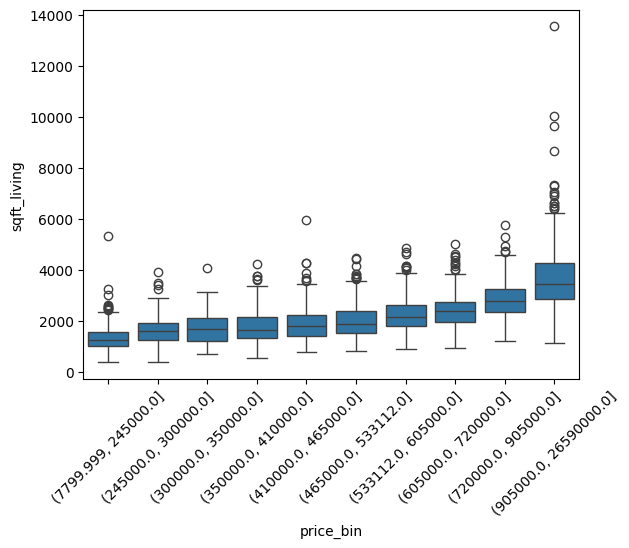

In [17]:
data["price_bin"] = pd.qcut(data["price"], 10)

sns.boxplot(x="price_bin", y="sqft_living", data=data)
plt.xticks(rotation=45)
plt.show()

<Axes: xlabel='sqft_living', ylabel='price'>

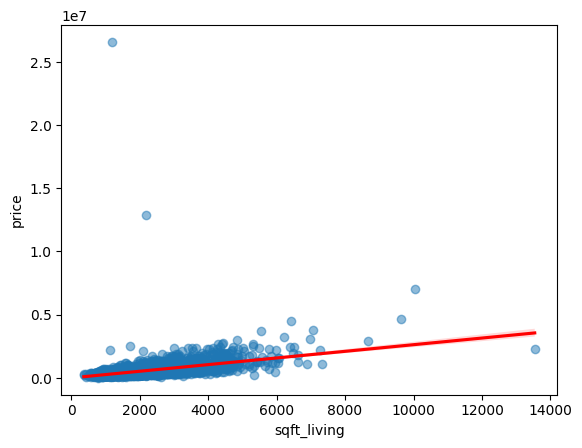

In [18]:
sns.regplot(x="sqft_living", y="price", data=data, 
            scatter_kws={'alpha':0.5}, # Makes points transparent
            line_kws={'color': 'red'})

<Axes: xlabel='log_sqft_living', ylabel='price'>

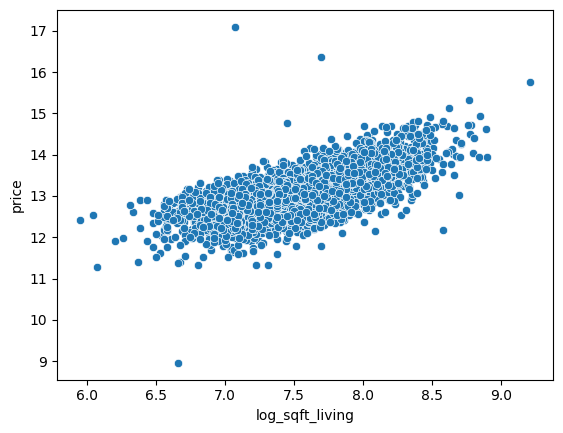

In [19]:
sns.scatterplot(data = X_train, y = y_train, x = X_train["log_sqft_living"])

log_sqft_living        0.122249
zip_freq               0.083618
yr_built               0.052049
area_premium           0.029710
log_sqft_above         0.023242
condition              0.021743
view                   0.014016
lot_to_living_ratio    0.009689
log_sqft_lot           0.008717
bathrooms              0.004811
bed_to_bath_ratio      0.004331
is_luxury              0.003229
waterfront             0.002732
house_age              0.002346
floors                 0.000223
has_basement           0.000070
bedrooms              -0.000307
yr_renovated          -0.000940
dtype: float64


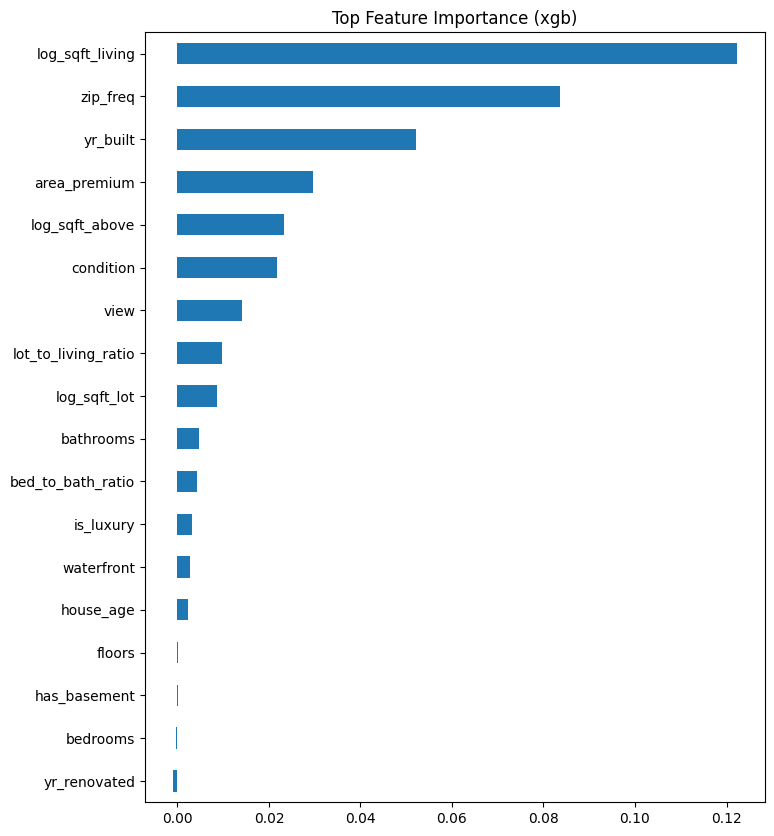

In [20]:
from sklearn.inspection import permutation_importance

result = permutation_importance(
    grid_xgb,
    X_test_model,
    y_test,
    n_repeats=10,
    random_state=42
)

perm_importance = pd.Series(
    result.importances_mean,
    index=X_test_model.columns
).sort_values(ascending=False)

print(perm_importance.head(100))

import matplotlib.pyplot as plt

perm_importance.head(100).plot(kind="barh", figsize=(8,10))
plt.title("Top Feature Importance (xgb)")
plt.gca().invert_yaxis()
plt.show()

In [21]:
analysis_df = X_test_model.copy()

analysis_df["actual"] = y_test
analysis_df["pred"] = test_pred
analysis_df["error"] = analysis_df["actual"] - analysis_df["pred"]
analysis_df["abs_error"] = np.abs(analysis_df["error"])

In [22]:
analysis_df.sort_values("abs_error", ascending=False).head(10)

,bedrooms,bathrooms,floors,waterfront,view,condition,yr_built,yr_renovated,house_age,log_sqft_living,...,bed_to_bath_ratio,lot_to_living_ratio,has_basement,zip_freq,area_premium,is_luxury,actual,pred,error,abs_error
4345,4.0,2.00,2.0,0,0,4,1953,1983,72,7.875119,...,1.333333,6.261878,0,52,409.506203,0.794418,11.342742,13.756814,-2.414072,2.414072
4348,4.0,1.50,1.0,0,0,3,1969,2014,56,7.021976,...,1.600000,4.841213,0,72,505.582302,0.338307,14.603923,12.292168,2.311755,2.311755
4347,4.0,1.00,1.0,0,0,3,1959,1989,66,7.650169,...,2.000000,4.378867,1,59,451.359953,0.634326,14.562199,12.657292,1.904907,1.904907
4402,3.0,1.50,1.5,0,0,3,1932,0,93,7.696667,...,1.200000,2.271695,0,53,407.923355,0.664532,12.170451,13.591267,-1.420816,1.420816
1186,3.0,1.75,1.0,0,0,3,1973,2013,52,7.384610,...,1.090909,4.469274,1,57,420.922792,0.486317,13.981449,12.583985,1.397464,1.397464
402,2.0,1.00,1.0,0,0,1,1928,0,97,6.698268,...,1.000000,9.839704,0,40,267.930722,0.244669,12.449023,11.091378,1.357645,1.357645
4456,4.0,1.00,1.5,0,0,4,1923,0,102,7.340187,...,2.000000,74.908501,0,52,381.689715,0.465172,11.794345,13.147605,-1.353259,1.353259
2654,5.0,6.75,1.0,1,4,3,1983,2009,42,9.173780,...,0.645161,1.355461,1,59,541.253027,2.911859,15.356241,14.346178,1.010063,1.010063
4042,4.0,2.25,2.0,0,0,3,2013,1923,12,7.766841,...,1.230769,1.694197,0,57,442.709911,0.712862,14.077876,13.069376,1.008500,1.008500
4576,3.0,3.00,2.0,0,0,5,1977,0,48,7.812378,...,0.750000,2.998786,1,103,804.674955,0.746088,12.409018,13.372409,-0.963391,0.963391


In [23]:
analysis_df["price_range"] = pd.qcut(
    analysis_df["actual"], 3, labels=["low", "mid", "high"]
)

analysis_df.groupby("price_range")["abs_error"].mean()

C:\Users\suryansh\AppData\Local\Temp\ipykernel_8304\3775815922.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  analysis_df.groupby("price_range")["abs_error"].mean()


price_range
low     0.253974
mid     0.166463
high    0.242660
Name: abs_error, dtype: float64

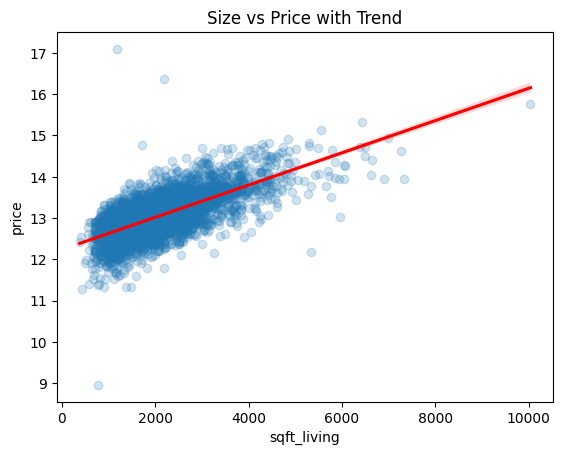

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure()
sns.regplot(
    x=X_train["sqft_living"],
    y=y_train,
    line_kws={'color': 'red'},
    scatter_kws={"alpha": 0.2}
)
plt.title("Size vs Price with Trend")
plt.show()

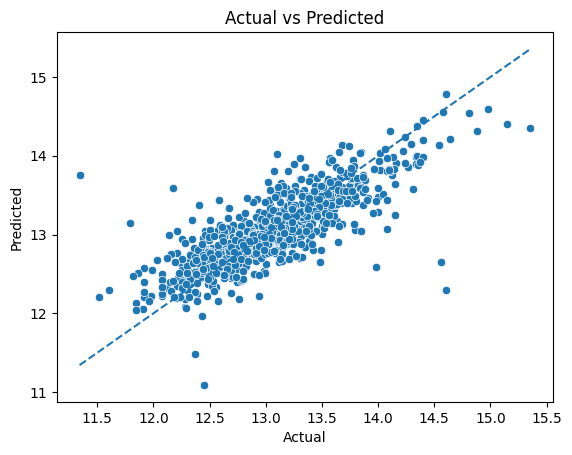

In [25]:
plt.figure()
sns.scatterplot(x=y_test, y=test_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")

# perfect prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    '--'
)

plt.show()

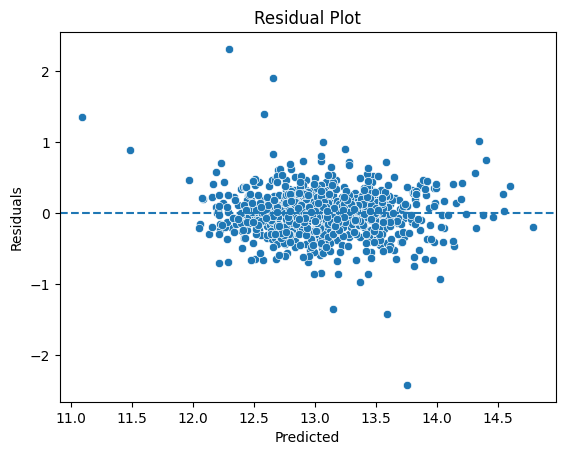

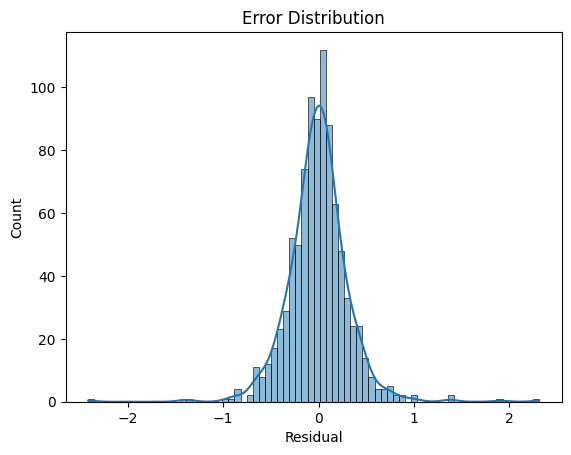

In [26]:
residuals = y_test - test_pred

plt.figure()
sns.scatterplot(x=test_pred, y=residuals)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()


plt.figure()
sns.histplot(residuals, kde=True)
plt.title("Error Distribution")
plt.xlabel("Residual")
plt.show()

In [27]:
model = XGBRegressor(
    n_estimators=500,
    learning_rate = 0.03,
    model__n_estimators = 500,
    model__learning_rate = 0.03,
    model__max_depth = 5,
    model__subsample = 0.8,
    model__colsample_bytree = 0.8
)

model.fit(
    X_train_model,
    y_train,
    eval_set=[(X_train_model, y_train), (X_test_model, y_test)],
    verbose=False
)

c:\Users\suryansh\AppData\Local\Programs\Python\Python310\lib\site-packages\xgboost\training.py:200: UserWarning: [21:46:42] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "model__colsample_bytree", "model__learning_rate", "model__max_depth", "model__n_estimators", "model__subsample" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


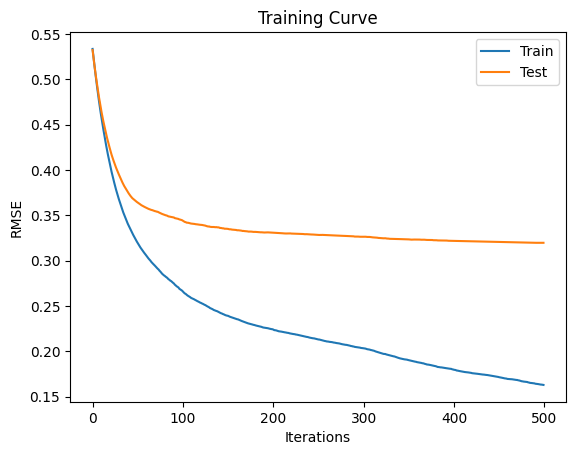

In [28]:
results = model.evals_result()

plt.figure()
plt.plot(results['validation_0']['rmse'], label='Train')
plt.plot(results['validation_1']['rmse'], label='Test')
plt.xlabel("Iterations")
plt.ylabel("RMSE")
plt.title("Training Curve")
plt.legend()
plt.show()

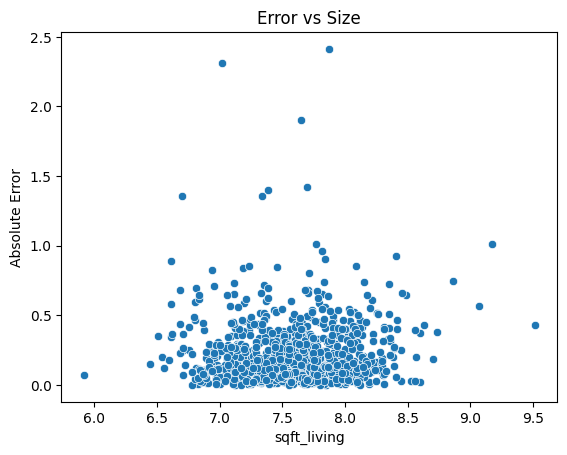

In [29]:
plt.figure()
sns.scatterplot(x=X_test_model["log_sqft_living"], y=abs(residuals))
plt.xlabel("sqft_living")
plt.ylabel("Absolute Error")
plt.title("Error vs Size")
plt.show()

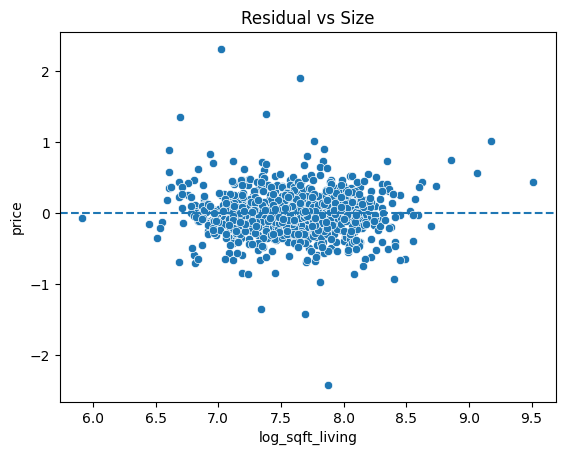

In [30]:
plt.figure()
sns.scatterplot(x=X_test_model["log_sqft_living"], y=residuals)
plt.axhline(0, linestyle="--")
plt.title("Residual vs Size")
plt.show()

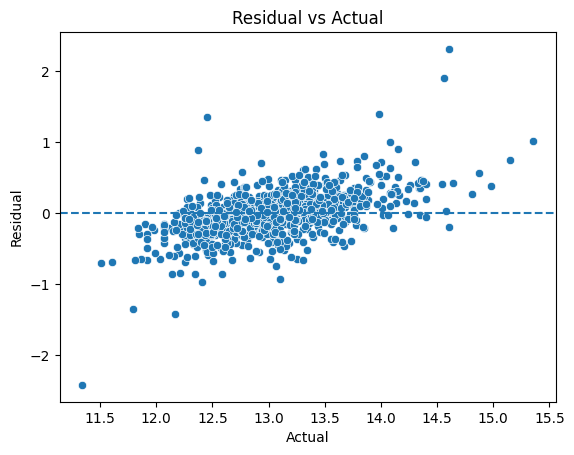

In [31]:
plt.figure()
sns.scatterplot(x=y_test, y=residuals)
plt.axhline(0, linestyle="--")
plt.xlabel("Actual")
plt.ylabel("Residual")
plt.title("Residual vs Actual")
plt.show()

C:\Users\suryansh\AppData\Local\Temp\ipykernel_8304\757830238.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  analysis_df.groupby("quantile")["abs_error"].mean().plot(kind="bar")


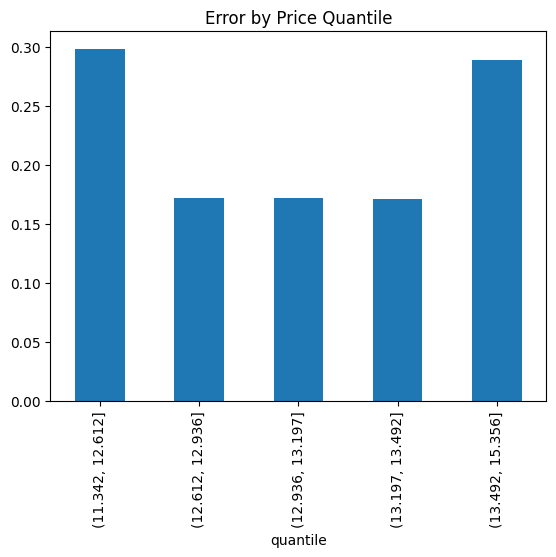

In [32]:
analysis_df["quantile"] = pd.qcut(analysis_df["actual"], 5)

analysis_df.groupby("quantile")["abs_error"].mean().plot(kind="bar")
plt.title("Error by Price Quantile")
plt.show()

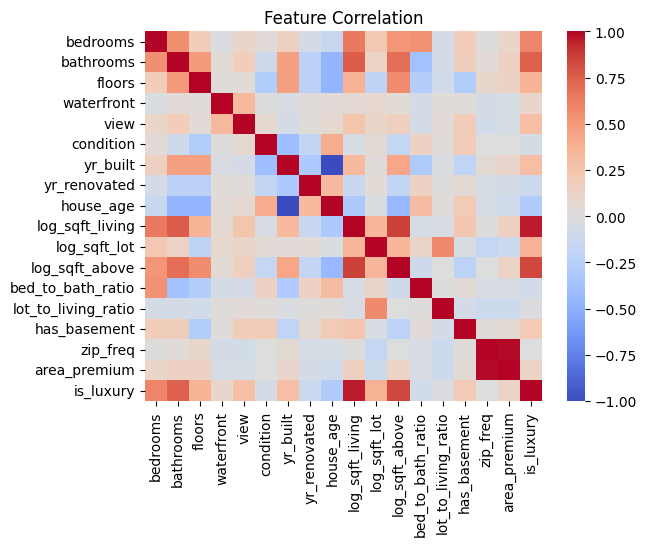

In [33]:
plt.figure()
sns.heatmap(X_train_model.corr(), cmap="coolwarm")
plt.title("Feature Correlation")
plt.show()

Text(0.5, 1.0, 'Error vs Location Density')

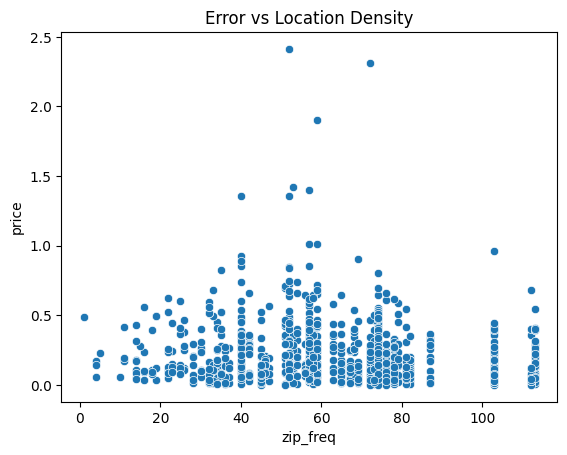

In [34]:
sns.scatterplot(x=X_test_model["zip_freq"], y=abs(residuals))
plt.title("Error vs Location Density")

In [35]:





pickle.dump(zip_mean, open("zip_mean.pkl", "wb"))
pickle.dump(zip_freq, open("zip_freq.pkl", "wb"))

pickle.dump(luxury_threshold, open("luxury_threshold.pkl", "wb"))

known_zipcodes = list(zip_mean.keys())

pickle.dump(known_zipcodes, open("known_zipcodes.pkl", "wb"))